# Bike Sharing Demand — Exploratory Data Analysis

Phase 2 EDA notebook for CMP4336. Uses the production data and preprocessing helpers from `src/bike_sharing/` rather than redefining pipeline contracts. Figures are written to `reports/figures/` for the project report.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bike_sharing.config import load_config
from bike_sharing.data import load_raw_train
from bike_sharing.preprocessing import drop_leakage_columns

# Walk up from the notebook to find the project root (where config/ lives).
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config" / "config.yaml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate config/config.yaml above cwd.")
    PROJECT_ROOT = PROJECT_ROOT.parent

CFG = load_config(PROJECT_ROOT / "config" / "config.yaml")
FIG_DIR = Path(CFG["paths"]["reports_dir"]) / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid")
print("project root:", PROJECT_ROOT)
print("figures will be saved under:", FIG_DIR)


project root: /Users/gokturkberkekorkut/bike-sharing-demand-forecasting
figures will be saved under: /Users/gokturkberkekorkut/bike-sharing-demand-forecasting/reports/figures


## 1. Load and basic checks

Confirm the data contract holds: train shape (10886, 12), all expected columns present, and no missing values.

In [2]:
df = load_raw_train(CFG)
print("shape:", df.shape)
print("missing values total:", int(df.isna().sum().sum()))
print()
print("dtypes:")
print(df.dtypes)
df.head()


shape: (10886, 12)
missing values total: 0

dtypes:
datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 2. Leakage sanity check

`casual + registered == count` in every row of the training data. The production helper `drop_leakage_columns` strips both columns so they can never enter the feature matrix for the count model. `count` itself stays on the frame because it is the modeling target; it gets removed from `X` only at fit time.

In [3]:
# Sanity check: casual + registered == count exactly, on every row.
assert (df["casual"] + df["registered"] == df["count"]).all()

df_safe = drop_leakage_columns(df, CFG)
print("columns dropped by drop_leakage_columns:",
      sorted(set(df.columns) - set(df_safe.columns)))
print("safe frame shape (still includes target 'count'):", df_safe.shape)


columns dropped by drop_leakage_columns: ['casual', 'registered']
safe frame shape (still includes target 'count'): (10886, 10)


## 3. Target distribution

`count` is heavily right-skewed (skew ≈ +1.24): many low-demand hours, a long tail of high-demand hours. Applying `log1p` reduces the strong right skew (skew ≈ -0.85) — the result is not perfectly symmetric, but it is much friendlier for squared-error losses and motivates reporting RMSLE alongside RMSE/MAE/R². The modeling pipeline trains on `log1p(count)` and inverts with `expm1`.

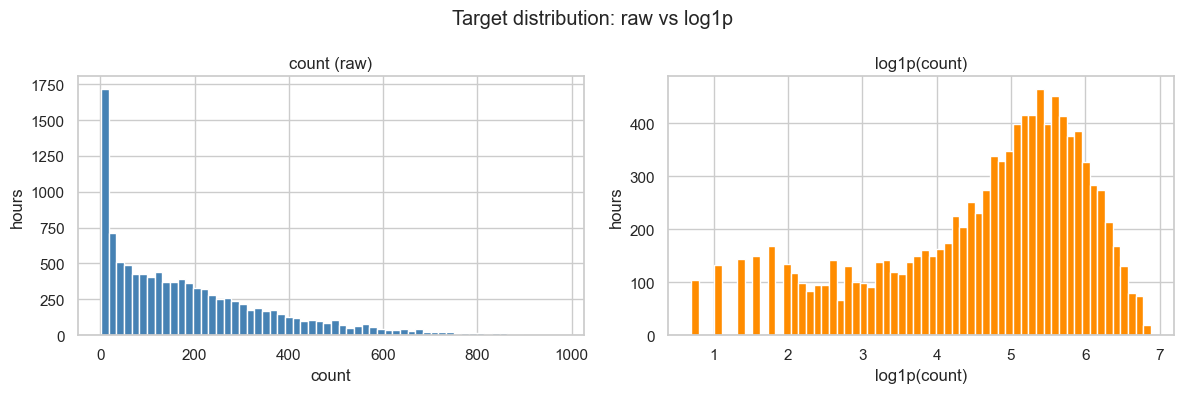

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["count"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("count (raw)")
axes[0].set_xlabel("count")
axes[0].set_ylabel("hours")

axes[1].hist(np.log1p(df["count"]), bins=60, color="darkorange", edgecolor="white")
axes[1].set_title("log1p(count)")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("hours")

fig.suptitle("Target distribution: raw vs log1p")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_count_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Hourly demand pattern

Splitting by `workingday` exposes two very different daily shapes: a sharp commuter rush pattern on working days (peaks near 8 and 17) and a smoother single-peak afternoon pattern on non-working days. This motivates a `workingday * hour` interaction or, at minimum, separate hour features in tree models.

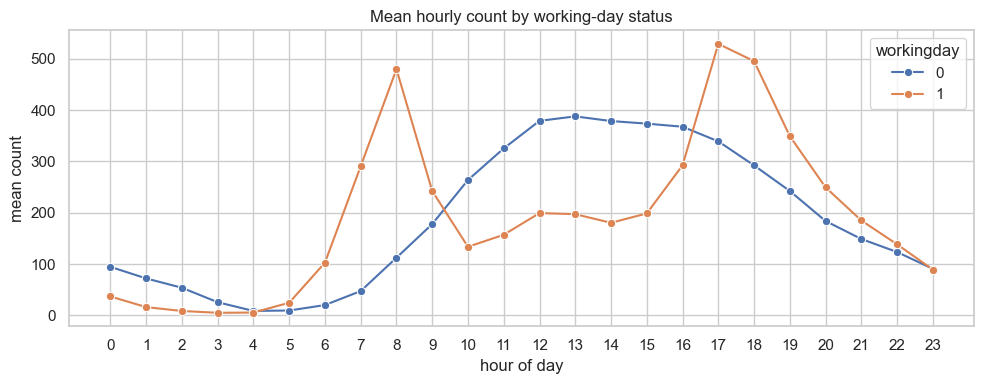

In [5]:
df = df.assign(
    hour=df["datetime"].dt.hour,
    dayofweek=df["datetime"].dt.dayofweek,
    month=df["datetime"].dt.month,
)

hourly = (
    df.groupby(["hour", "workingday"], as_index=False)["count"].mean()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    data=hourly, x="hour", y="count", hue="workingday", marker="o", ax=ax
)
ax.set_title("Mean hourly count by working-day status")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean count")
ax.set_xticks(range(0, 24))
ax.legend(title="workingday")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_hourly_pattern.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Seasonal / monthly pattern

Demand grows from winter to summer and stays elevated through fall, consistent with weather-driven outdoor activity. The yearly trend and month seasonality are both signal sources worth encoding as features.

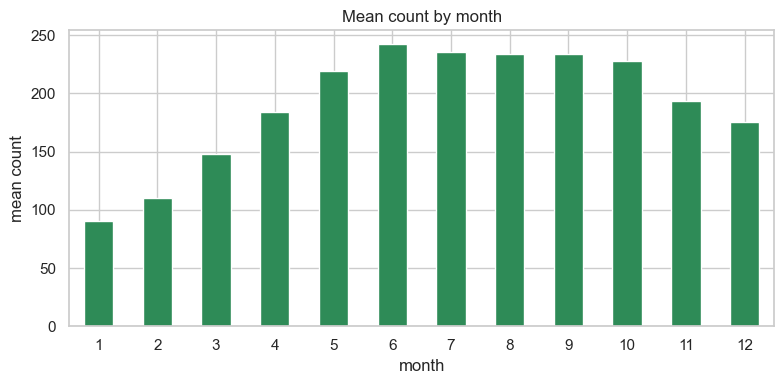

In [6]:
monthly = df.groupby("month")["count"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
monthly.plot(kind="bar", color="seagreen", ax=ax)
ax.set_title("Mean count by month")
ax.set_xlabel("month")
ax.set_ylabel("mean count")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_monthly_pattern.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Weather impact

Weather is encoded as 1=clear, 2=mist/cloudy, 3=light rain/snow, 4=heavy rain/snow. Categories 1-3 show a monotonic decline in both the mean and median of `count`. Category 4 holds only one row in the training data (n=1), so its boxplot is a single point and no conclusion can be drawn from it. The per-category sample counts are annotated under the plot.

observations per weather category:
weather
1    7192
2    2834
3     859
4       1


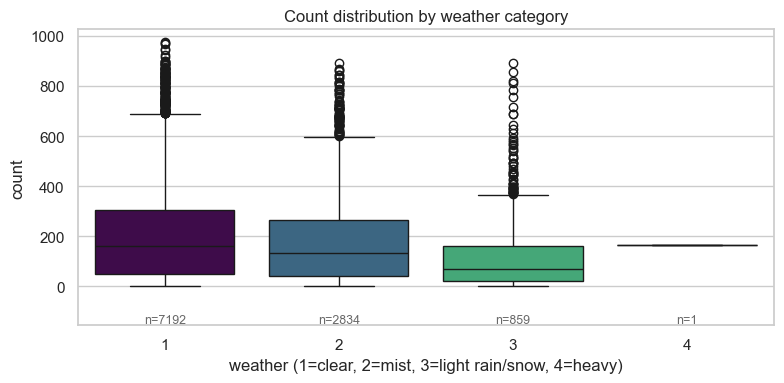

In [7]:
weather_counts = df["weather"].value_counts().sort_index()
print("observations per weather category:")
print(weather_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=df, x="weather", y="count",
    hue="weather", legend=False, palette="viridis", ax=ax,
)
ax.set_title("Count distribution by weather category")
ax.set_xlabel("weather (1=clear, 2=mist, 3=light rain/snow, 4=heavy)")
ax.set_ylabel("count")
# Annotate sample size under each category so a reader can see that
# category 4 has only one observation.
ymin, ymax = ax.get_ylim()
for i, (cat, n) in enumerate(weather_counts.items()):
    ax.text(i, ymin - 0.06 * (ymax - ymin), f"n={n}",
            ha="center", va="top", fontsize=9, color="dimgray")
ax.set_ylim(ymin - 0.10 * (ymax - ymin), ymax)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_weather_impact.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Correlation heatmap

Pearson correlation of numeric predictors with `count`. `atemp` and `temp` are nearly collinear (correlation ≈ 0.98). Because the first linear model is Ridge, multicollinearity is handled by the L2 penalty and does not force dropping either column at this stage — the keep-both vs keep-one comparison is a Phase 4 CV decision. Humidity is negatively correlated with count; windspeed is weakly positively correlated.

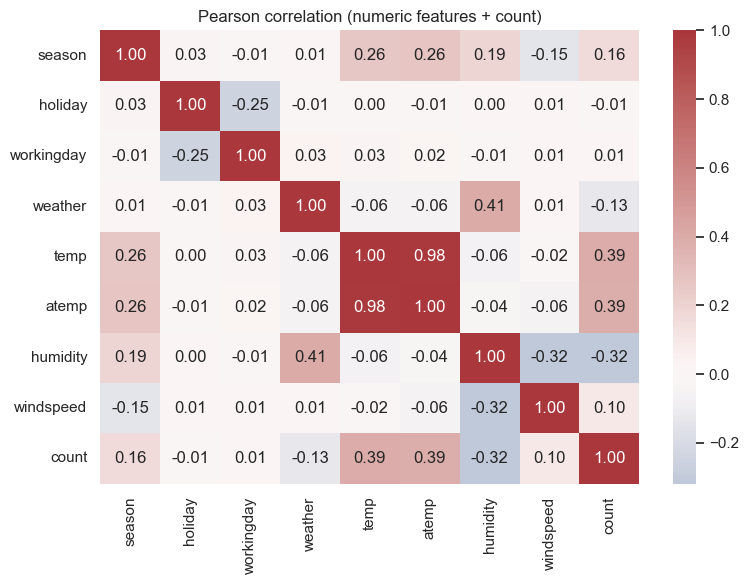

In [8]:
numeric_cols = [
    "season", "holiday", "workingday", "weather",
    "temp", "atemp", "humidity", "windspeed", "count",
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Pearson correlation (numeric features + count)")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


## Findings (feed into Phase 3 feature engineering)

- `count` is right-skewed (skew ≈ +1.24); `log1p` reduces the skew (to ≈ -0.85) and motivates reporting RMSLE alongside the other metrics, so train on `log1p(count)`.
- Hourly demand shows a strong working-day vs non-working-day split; encode `hour` explicitly and consider a cyclic (sin/cos) variant.
- Demand follows a clear seasonal arc; encode `month` and `year`.
- For categories 1-3, more severe weather lowers demand. Category 4 appears only once in training, so it informs neither feature engineering nor evaluation conclusions.
- `atemp` and `temp` are essentially collinear (≈ 0.98). Ridge handles multicollinearity through L2 regularization, so this is a Phase 4 CV decision (keep both vs drop one) rather than an EDA-time drop. Humidity is negatively correlated with demand.